In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
url="https://books.toscrape.com/"
response=requests.get(url)
print(response.status_code)

200


In [11]:
soup=BeautifulSoup(response.text,"html.parser")
print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [12]:
books=soup.find_all("article",class_="product_pod")
print("Number of books found:",len(books))

Number of books found: 20


In [13]:
for book in books:
  title=book.h3.a["title"]
  print(title)

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [14]:
for book in books:
  title=book.h3.a["title"]
  price=book.find("p",class_="price_color").text
  rating=book.find("p",class_="star-rating")["class"][1]

  print("Title:",title)
  print("Price:",price)
  print("Rating:",rating)
  print("_"*50)

Title: A Light in the Attic
Price: Â£51.77
Rating: Three
__________________________________________________
Title: Tipping the Velvet
Price: Â£53.74
Rating: One
__________________________________________________
Title: Soumission
Price: Â£50.10
Rating: One
__________________________________________________
Title: Sharp Objects
Price: Â£47.82
Rating: Four
__________________________________________________
Title: Sapiens: A Brief History of Humankind
Price: Â£54.23
Rating: Five
__________________________________________________
Title: The Requiem Red
Price: Â£22.65
Rating: One
__________________________________________________
Title: The Dirty Little Secrets of Getting Your Dream Job
Price: Â£33.34
Rating: Four
__________________________________________________
Title: The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
Price: Â£17.93
Rating: Three
__________________________________________________
Title: The Boys in the Boat: Nine Americans and Their E

In [15]:
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]
    availability = book.find("p", class_="instock availability").get_text(strip=True)

    print("Title:", title)
    print("Price:", price)
    print("Rating:", rating)
    print("Availability:", availability)
    print("-" * 50)

Title: A Light in the Attic
Price: Â£51.77
Rating: Three
Availability: In stock
--------------------------------------------------
Title: Tipping the Velvet
Price: Â£53.74
Rating: One
Availability: In stock
--------------------------------------------------
Title: Soumission
Price: Â£50.10
Rating: One
Availability: In stock
--------------------------------------------------
Title: Sharp Objects
Price: Â£47.82
Rating: Four
Availability: In stock
--------------------------------------------------
Title: Sapiens: A Brief History of Humankind
Price: Â£54.23
Rating: Five
Availability: In stock
--------------------------------------------------
Title: The Requiem Red
Price: Â£22.65
Rating: One
Availability: In stock
--------------------------------------------------
Title: The Dirty Little Secrets of Getting Your Dream Job
Price: Â£33.34
Rating: Four
Availability: In stock
--------------------------------------------------
Title: The Coming Woman: A Novel Based on the Life of the Infamous Fe

In [16]:
data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p")["class"][1]
    availability = book.find("p", class_="instock availability").get_text(strip=True)

    data.append({
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability
    })

df = pd.DataFrame(data)

print(df)

                                                Title    Price Rating  \
0                                A Light in the Attic  Â£51.77  Three   
1                                  Tipping the Velvet  Â£53.74    One   
2                                          Soumission  Â£50.10    One   
3                                       Sharp Objects  Â£47.82   Four   
4               Sapiens: A Brief History of Humankind  Â£54.23   Five   
5                                     The Requiem Red  Â£22.65    One   
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34   Four   
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93  Three   
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60   Four   
9                                     The Black Maria  Â£52.15    One   
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99    Two   
11                              Shakespeare's Sonnets  Â£20.66   Four   
12                                        Set Me Fr

In [17]:
# Number of rows and columns
print(df.shape)

(20, 4)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         20 non-null     object
 1   Price         20 non-null     object
 2   Rating        20 non-null     object
 3   Availability  20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [19]:
df.isnull().sum()

,0
Title,0
Price,0
Rating,0
Availability,0


In [20]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [21]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .astype(float)
)
df.head()


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [22]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

print(df[["Rating"]].head())

   Rating
0       3
1       1
2       1
3       4
4       5


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         20 non-null     object 
 1   Price         20 non-null     float64
 2   Rating        20 non-null     int64  
 3   Availability  20 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 772.0+ bytes


In [24]:
total_books = len(df)

print("Total Number of Books:", total_books)

Total Number of Books: 20


In [25]:
print("Average Price:", df["Price"].mean())

Average Price: 38.048500000000004


In [26]:
average_rating = df["Rating"].mean()

print("Average Rating:", average_rating)

Average Rating: 2.85


In [27]:
most_expensive = df.loc[df["Price"].idxmax()]

print("Most Expensive Book:")
print("Title:", most_expensive["Title"])
print("Price:", most_expensive["Price"])

Most Expensive Book:
Title: Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Price: 57.25


In [28]:
cheapest_book = df.loc[df["Price"].idxmin()]

print("Cheapest Book:")
print("Title:", cheapest_book["Title"])
print("Price:", cheapest_book["Price"])

Cheapest Book:
Title: Starving Hearts (Triangular Trade Trilogy, #1)
Price: 13.99


In [29]:
rating_distribution = df["Rating"].value_counts().sort_index()

print("Rating Distribution:")
print(rating_distribution)

Rating Distribution:
Rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


In [30]:
data = []

for page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Failed to load page {page}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a.get("title")

        price = book.find("p", class_="price_color")
        price = price.text if price else "N/A"

        rating = book.find("p", class_="star-rating")
        rating = rating["class"][1] if rating else "N/A"

        availability = book.find("p", class_="instock availability")
        availability = availability.get_text(strip=True) if availability else "N/A"

        data.append([title, price, rating, availability])

df = pd.DataFrame(
    data,
    columns=["Title", "Price", "Rating", "Availability"]
)

print(df.head())
print("Total Books:", len(df))


                                   Title    Price Rating Availability
0                   A Light in the Attic  Â£51.77  Three     In stock
1                     Tipping the Velvet  Â£53.74    One     In stock
2                             Soumission  Â£50.10    One     In stock
3                          Sharp Objects  Â£47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  Â£54.23   Five     In stock
Total Books: 1000


In [31]:
df=pd.DataFrame(data)
df.head()

,0,1,2,3
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [32]:
print("Dataset Size:", df.shape)

Dataset Size: (1000, 4)


In [33]:
print("data exists:", "data" in globals())
print("df exists:", "df" in globals())

data exists: True
df exists: True


In [34]:
print(df.shape)

(1000, 4)


In [35]:
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

RangeIndex(start=0, stop=4, step=1)

Data Types:
0    object
1    object
2    object
3    object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       1000 non-null   object
 1   1       1000 non-null   object
 2   2       1000 non-null   object
 3   3       1000 non-null   object
dtypes: object(4)
memory usage: 31.4+ KB


In [36]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0


In [37]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [39]:
df.columns = ["Title", "Price", "Rating", "Availability"]

print(df.columns)

Index(['Title', 'Price', 'Rating', 'Availability'], dtype='object')


In [40]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [41]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print(df.dtypes)

Title            object
Price           float64
Rating           object
Availability     object
dtype: object


In [42]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()

print("\nDataset shape after removing missing values:")
print(df.shape)

Missing values before cleaning:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64

Dataset shape after removing missing values:
(1000, 4)


In [43]:
clean_df = df.copy()

print("Final Clean Dataset Shape:")
print(clean_df.shape)

clean_df.head()

Final Clean Dataset Shape:
(1000, 4)


,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [44]:
clean_df.describe()

,Price
count,1000.00000
mean,35.07035
std,14.44669
min,10.00000
25%,22.10750
50%,35.98000
75%,47.45750
max,59.99000


In [45]:
print("Average Price:", round(clean_df["Price"].mean(), 2))
print("Median Price:", round(clean_df["Price"].median(), 2))
print("Highest Price:", clean_df["Price"].max())
print("Lowest Price:", clean_df["Price"].min())

Average Price: 35.07
Median Price: 35.98
Highest Price: 59.99
Lowest Price: 10.0


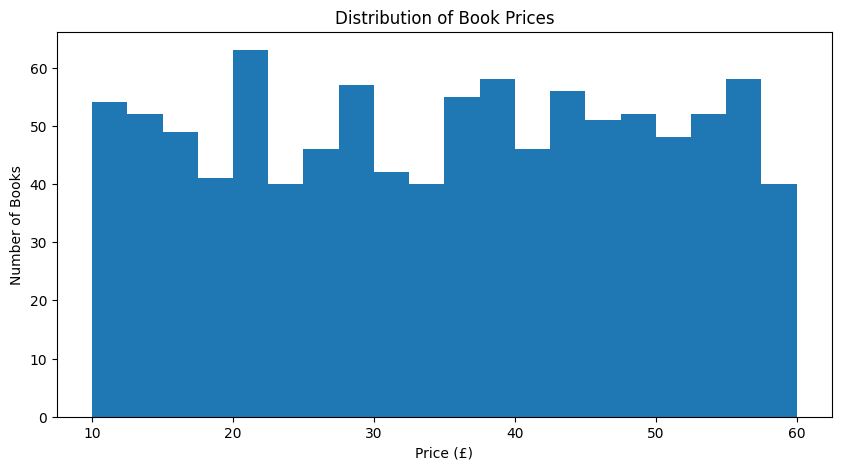

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(clean_df["Price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [47]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

clean_df["Rating_Numeric"] = clean_df["Rating"].map(rating_map)

clean_df.head()

,Title,Price,Rating,Availability,Rating_Numeric
0,A Light in the Attic,51.77,Three,In stock,3
1,Tipping the Velvet,53.74,One,In stock,1
2,Soumission,50.10,One,In stock,1
3,Sharp Objects,47.82,Four,In stock,4
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock,5


In [48]:
clean_df.to_csv("books_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [49]:
from google.colab import files

files.download("books_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
print("Dataset Shape:", clean_df.shape)

print("\nMissing Values:")
print(clean_df.isnull().sum())

print("\nDuplicate Records:")
print(clean_df.duplicated().sum())

Dataset Shape: (1000, 5)

Missing Values:
Title             0
Price             0
Rating            0
Availability      0
Rating_Numeric    0
dtype: int64

Duplicate Records:
0


In [51]:
print("""
PROJECT SUMMARY

Website Scraped: Books to Scrape
Total Records Collected: 1000

Columns:
- Title
- Price
- Rating
- Availability
- Rating_Numeric

Activities Completed:
✓ Web Scraping
✓ Data Collection
✓ Data Cleaning
✓ Data Validation
✓ Exploratory Data Analysis
✓ Data Visualization
✓ CSV Export
""")


PROJECT SUMMARY

Website Scraped: Books to Scrape
Total Records Collected: 1000

Columns:
- Title
- Price
- Rating
- Availability
- Rating_Numeric

Activities Completed:
✓ Web Scraping
✓ Data Collection
✓ Data Cleaning
✓ Data Validation
✓ Exploratory Data Analysis
✓ Data Visualization
✓ CSV Export



In [52]:
print("""
CONCLUSION

A complete web scraping project was successfully performed using Python,
Requests, BeautifulSoup, Pandas, and Matplotlib.

Book information was extracted from multiple pages,
organized into a structured dataset,
cleaned and validated,
analyzed using summary statistics,
visualized through charts,
and exported as a CSV file for future analysis.

The project demonstrates practical skills in
web scraping, data wrangling, exploratory data analysis,
and dataset creation.
""")


CONCLUSION

A complete web scraping project was successfully performed using Python,
Requests, BeautifulSoup, Pandas, and Matplotlib.

Book information was extracted from multiple pages,
organized into a structured dataset,
cleaned and validated,
analyzed using summary statistics,
visualized through charts,
and exported as a CSV file for future analysis.

The project demonstrates practical skills in
web scraping, data wrangling, exploratory data analysis,
and dataset creation.



In [54]:
print(clean_df.shape)
clean_df.head()
clean_df.info()

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Title           1000 non-null   object 
 1   Price           1000 non-null   float64
 2   Rating          1000 non-null   object 
 3   Availability    1000 non-null   object 
 4   Rating_Numeric  1000 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 39.2+ KB
